# AthleAgent — ML Journey (presentation)

**Live demo** for the instructor — not a second training pipeline.

| Layer | What it is |
|-------|------------|
| **This notebook** | Config, plots, tables, narrative |
| **`train_model.py`** | Real training + tiered model selection (same as `run_pipeline.py`) |
| **`policy_config.py`** | Production gate constants |

Edit **Configuration** below, then *Run All*. Parts 5–6 replay the algorithm on a demo slice; **Part 7** loads the promoted full-run artifacts (feature weights, threshold, calibration) that shipped to production.


## Configuration

Self-contained settings for this presentation. **No project imports in this cell** — change values here, then re-run from **Bootstrap** onward.


In [ ]:
# =============================================================================
# PRESENTATION CONFIG — edit here before Run All
# =============================================================================

# Demo data slice (fast enough for a live class run)
DEMO_CONFIG = {
    "fixture_relpath": "fixtures/athlete_injury_demo.csv",
    "subset_athletes": 50,
    "subset_days": 120,
    "holdout_ratio": 0.20,
    "random_seed": 42,
}

# Model-selection policy gates (production — promoted run 20260629_184034)
POLICY_CONFIG = {
    "MIN_RECALL_HARD": 0.80,
    "TARGET_RECALL": 0.80,
    "MAX_FPR_OPERATING": 0.55,
    "TARGET_PRECISION": 0.13,
    "TARGET_F1": 0.22,
    "THRESHOLD": 0.18,
    "MIN_AUC_FOR_LIVE": 0.68,
}

# Production reference (informational; demo slice may pick a different winner)
PRODUCTION_REF = {
    "promoted_run_id": "20260629_184034",
    "promoted_winner": "XGBoostCalibratedTuned",
    "operating_threshold": 0.10,
    "dataset_rows": 359_000,
}


## Bootstrap — imports from the repo

The notebook **does not re-implement** training. It calls production modules:

| Import | Purpose |
|--------|--------|
| `train_model.py` | `load_dataset`, `make_train_split`, `train_and_compare`, `pick_best_model`, gate tables |
| `policy_config.py` | applies `POLICY_CONFIG` above into the live policy singleton |
| `services.model_features` | 35-feature contract shared with the backend |

Everything below this cell is either a project function call or presentation-only plotting.


In [ ]:
# pip install pandas numpy matplotlib jupyter ipykernel xgboost scikit-learn  (one-time)
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

# --- resolve repo paths ---
_here = Path.cwd().resolve()
ML_ROOT = next(
    cand
    for cand in (
        _here / "ML_model",
        _here.parent / "ML_model",
        *(_here.parents[i] / "ML_model" for i in range(len(_here.parents))),
    )
    if (cand / "data_generator.py").is_file()
)
PROJECT_ROOT = ML_ROOT.parent
sys.path.insert(0, str(ML_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

# --- project imports (training + policy) ---
import policy_config as _policy_config  # noqa: E402
import train_model as _train_model  # noqa: E402
importlib.reload(_policy_config)
importlib.reload(_train_model)

from policy_config import apply_policy_overrides, get_policy, policy_thresholds, reset_policy  # noqa: E402
from train_model import (  # noqa: E402
    LABEL_COLUMN,
    OPERATING_TIER_LABELS,
    RANDOM_STATE,
    add_selection_column,
    build_fixed_threshold_gate_table,
    build_operating_points_table,
    load_dataset,
    make_train_split,
    model_catalog,
    pick_best_model,
    subset_dataset,
    train_and_compare,
)
from services.model_features import MODEL_FEATURE_COLUMNS  # noqa: E402

# --- apply Configuration cell into runtime ---
SEED = DEMO_CONFIG["random_seed"]
SUBSET_ATHLETES = DEMO_CONFIG["subset_athletes"]
SUBSET_DAYS = DEMO_CONFIG["subset_days"]
HOLDOUT_RATIO = DEMO_CONFIG["holdout_ratio"]
DATA_PATH = ML_ROOT / DEMO_CONFIG["fixture_relpath"]
LABEL_COL = LABEL_COLUMN

PRODUCTION_ARTIFACTS_DIR = ML_ROOT / "artifacts" / PRODUCTION_REF["promoted_run_id"]
PRODUCTION_MANIFEST_PATH = PRODUCTION_ARTIFACTS_DIR / "run_manifest.json"

reset_policy()
apply_policy_overrides(**POLICY_CONFIG)

# --- presentation-only helpers (not in train_model.py) ---
def show_gates(df: pd.DataFrame, cols: list[str]) -> None:
    view = df.copy()
    for col in cols:
        if col in view.columns:
            view[col] = view[col].map({True: "PASS", False: "FAIL"})
    display(view)


def fixed_comparison_threshold() -> float:
    return get_policy().THRESHOLD


def display_active_policy_gates(title: str = "Active policy gates") -> None:
    gates = policy_thresholds()
    display(Markdown(f"**{title}**"))
    display(pd.DataFrame([
        ("Recall hard minimum", gates["recall_hard_min"], "Must catch ≥80% of holdout injuries @ operating point"),
        ("Recall target", gates["recall_target"], "Tier-0 target"),
        ("FPR maximum @ operating", gates["fpr_max_operating"], "Limit false alarms"),
        ("Precision minimum", gates["precision_min"], "When all gates pass (Tier 0)"),
        ("F1 minimum", gates["f1_min"], "When all gates pass (Tier 0)"),
        ("Fixed comparison threshold", gates["fixed_comparison_threshold"], "Baseline table before sweep tuning"),
        ("AUC minimum for live", gates["auc_min_for_live"], "Backend serving gate"),
    ], columns=["Gate", "Value", "Why"]))


RISK_BIN_PRESENTATION = {
    "green_0_20": ("0% – 20%", "Low", "🟢"),
    "yellow_20_50": ("21% – 50%", "Medium", "🟡"),
    "red_50_100": ("51% – 100%", "High", "🔴"),
}


def format_risk_bins_table(risk_bins_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in risk_bins_df.iterrows():
        score_range, ui_level, icon = RISK_BIN_PRESENTATION.get(
            str(row["bin"]), (str(row["bin"]), "", "")
        )
        rows.append({
            "Risk score range": score_range,
            "UI band": f"{icon} {ui_level}".strip(),
            "Observed injury rate (holdout)": f"~{row['injury_rate']:.0%}",
        })
    return pd.DataFrame(rows)


def plot_feature_correlation_heatmap(
    df: pd.DataFrame,
    feature_cols: list[str],
    label_col: str,
    *,
    top_n: int | None = 20,
    title: str = "Feature correlation heatmap",
) -> None:
    """Pearson correlation matrix (presentation). top_n=None shows all contract features."""
    cols = [c for c in feature_cols if c in df.columns]
    if not cols:
        raise ValueError("No model feature columns found in dataframe")
    frame = df[cols + [label_col]].copy()
    if top_n is not None and len(cols) > top_n:
        ranked = frame[cols + [label_col]].corr()[label_col].drop(label_col).abs().sort_values(ascending=False)
        cols = ranked.head(top_n).index.tolist()
        frame = df[cols + [label_col]]
    matrix = frame.corr()
    n = len(matrix)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.42), max(7, n * 0.38)))
    im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(matrix.index, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_injury_rate_by_feature_bins(
    df: pd.DataFrame,
    feature: str,
    label_col: str,
    *,
    n_bins: int = 5,
) -> None:
    """Injury rate across feature quintiles — quick calibration-style EDA."""
    if feature not in df.columns:
        raise ValueError(f"Missing feature column: {feature}")
    tmp = df[[feature, label_col]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")
    summary = tmp.groupby("bin", observed=True)[label_col].agg(["mean", "count"]).reset_index()
    summary["bin_label"] = summary["bin"].astype(str)
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.bar(range(len(summary)), summary["mean"], color="steelblue", alpha=0.85)
    ax1.set_ylabel("Injury rate")
    ax1.set_xlabel(f"{feature} (quintiles, low → high)")
    ax1.set_title(f"Injury rate by {feature} bins")
    ax1.set_xticks(range(len(summary)))
    ax1.set_xticklabels([f"Q{i+1}\n(n={int(c)})" for i, c in enumerate(summary["count"])], fontsize=9)
    ax1.set_ylim(0, max(0.05, summary["mean"].max() * 1.25))
    plt.tight_layout()
    plt.show()


def load_production_manifest() -> dict:
    with open(PRODUCTION_MANIFEST_PATH, encoding="utf-8") as f:
        return json.load(f)


def production_winner_metrics_table(manifest: dict) -> pd.DataFrame:
    rows = [{"Metric": k, "Value": v} for k, v in manifest["winner_metrics"].items()]
    return pd.DataFrame(rows)


def score_production_on_benchmark_holdout() -> tuple[pd.Series, np.ndarray, float] | None:
    """Score the promoted model on the production holdout (benchmark athlete split)."""
    pkl_path = PRODUCTION_ARTIFACTS_DIR / "injury_model.pkl"
    dataset_path = ML_ROOT / "athlete_injury_data.csv"
    bench_path = ML_ROOT / "benchmark_holdout.csv"
    if not pkl_path.is_file() or not dataset_path.is_file():
        return None
    df = load_dataset(dataset_path)
    split = make_train_split(
        df,
        benchmark_path=bench_path if bench_path.is_file() else None,
        seed=RANDOM_STATE,
    )
    bundle = joblib.load(pkl_path)
    cols = bundle["feature_columns"]
    X_test = split.X_test[cols]
    proba = bundle["estimator"].predict_proba(X_test)[:, 1]
    threshold = float(bundle.get("threshold", PRODUCTION_REF["operating_threshold"]))
    return split.y_test, proba, threshold


def plot_calibration_from_artifact(
    cal_df: pd.DataFrame,
    model_name: str,
    *,
    title: str,
) -> None:
    sub = cal_df[cal_df["model"] == model_name].sort_values("mean_predicted_risk")
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
    ax.plot(sub["mean_predicted_risk"], sub["fraction_positive"], "o-", label=model_name)
    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed injury rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_pr_curve(
    y_true: pd.Series,
    y_proba: np.ndarray,
    *,
    operating_threshold: float,
    title: str,
) -> None:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    y_pred_op = (y_proba >= operating_threshold).astype(int)
    op_prec = precision_score_safe(y_true, y_pred_op)
    op_rec = recall_score_safe(y_true, y_pred_op)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, lw=2, label=f"PR curve (AP={ap:.3f})")
    ax.scatter([op_rec], [op_prec], s=80, c="crimson", zorder=5, label=f"@ threshold {operating_threshold:.2f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(loc="lower left")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


def precision_score_safe(y_true: pd.Series, y_pred: np.ndarray) -> float:
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return tp / (tp + fp) if (tp + fp) else 0.0


def recall_score_safe(y_true: pd.Series, y_pred: np.ndarray) -> float:
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp / (tp + fn) if (tp + fn) else 0.0


def plot_confusion_at_threshold(
    y_true: pd.Series,
    y_proba: np.ndarray,
    threshold: float,
    *,
    title: str,
) -> None:
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: no injury", "Pred: injury"])
    ax.set_yticklabels(["Actual: no injury", "Actual: injury"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black", fontsize=12)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_threshold_sweep_metric(
    sweep_df: pd.DataFrame,
    model_name: str,
    metric: str = "F1",
    *,
    operating_threshold: float | None = None,
) -> None:
    sub = sweep_df[sweep_df["Model"] == model_name].sort_values("Threshold")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sub["Threshold"], sub[metric], marker="o", ms=3)
    if operating_threshold is not None:
        ax.axvline(operating_threshold, color="crimson", ls="--", lw=1, label="operating threshold")
        ax.legend()
    ax.set_xlabel("Threshold")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs threshold — {model_name}")
    plt.tight_layout()
    plt.show()

# --- run state (filled by later cells) ---
train_result = None
split = None
df_demo = None
fixed_gates = None
operating_table = None
WINNER = None
OPERATING_THRESHOLD = None

display(Markdown(
    f"Bootstrap OK — demo: `{DATA_PATH.name}`, "
    f"production ref: **{PRODUCTION_REF['promoted_winner']}** (run `{PRODUCTION_REF['promoted_run_id']}`)"
))
display_active_policy_gates("Policy applied from Configuration")

## Part 0 — Target

Predict `injury_today` on day D. We optimize for **catching injuries** without flooding athletes with false alarms.


## Part 1 — Load data (subset)

Uses **`fixtures/athlete_injury_demo.csv`** from git, then a smaller slice for fast training.


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Pull latest git or run: "
        "python ML_model/data_generator.py (full CSV, not required for this notebook)."
    )

df_raw = load_dataset(DATA_PATH)
df_demo = subset_dataset(df_raw, n_athletes=SUBSET_ATHLETES, max_days_per_athlete=SUBSET_DAYS, seed=SEED)

display(pd.Series({
    "source CSV": DATA_PATH.name,
    "full CSV rows": len(df_raw),
    "demo rows": len(df_demo),
    "demo athletes": df_demo["athlete_id"].nunique(),
    "injury-day rate": f"{df_demo[LABEL_COL].mean():.2%}",
}).to_frame("value"))
display(df_demo.head(5))


,value
source CSV,athlete_injury_demo.csv
full CSV rows,17280
demo rows,6000
demo athletes,50
injury-day rate,15.58%


,athlete_id,date,bmi,age,body_fat_pct,vo2_max,history_injury_count,injured_yesterday,daily_distance_km,workout_intensity_minutes,...,muscle_soreness,energy_level,injury_today,acute_load_7d,acwr_ratio,calorie_balance,sleep_debt_3d,hrv_drop,load_recovery_imbalance,speed_intensity_ratio
0,1,2025-01-07,20.38,27,10.1,65.1,0,0,4.90,28,...,6,10,0,4.068571,0.887058,581,0.8,4.142857,0.709646,1.361413
1,1,2025-01-08,20.38,27,9.9,64.5,0,0,4.76,28,...,9,9,0,4.035714,0.886487,384,1.7,-7.000000,1.507028,1.175970
2,1,2025-01-09,20.38,27,9.4,64.2,0,0,6.35,39,...,5,10,0,4.048571,0.885891,1298,3.0,9.142857,2.657672,1.319403
3,1,2025-01-10,20.38,27,9.8,64.8,0,0,0.06,0,...,5,7,0,3.952857,0.866326,938,2.2,-2.571429,1.905918,0.000000
4,1,2025-01-11,20.38,27,9.5,64.5,0,0,0.89,5,...,3,8,0,3.672857,0.829492,458,3.2,-3.857143,2.654374,1.371534


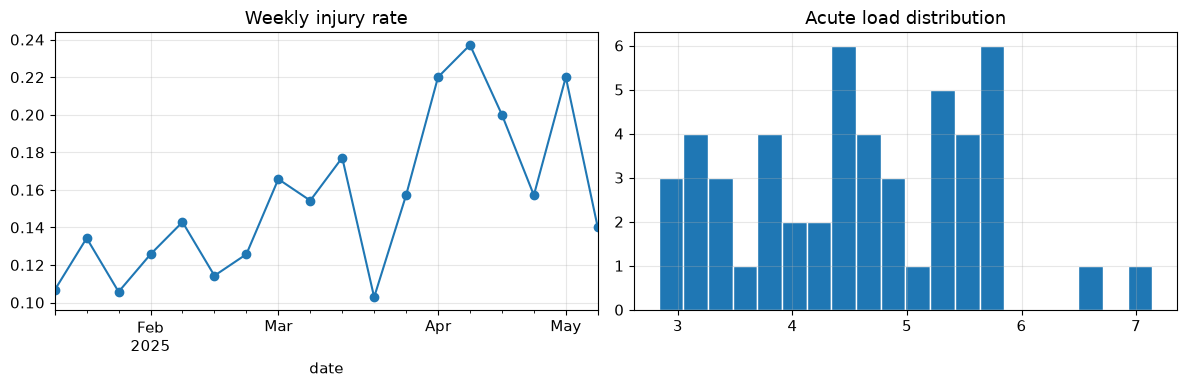

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_demo.groupby(df_demo["date"].dt.to_period("W"))[LABEL_COL].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Weekly injury rate")
df_demo.groupby("athlete_id")["acute_load_7d"].mean().hist(bins=20, ax=axes[1], edgecolor="white")
axes[1].set_title("Acute load distribution")
plt.tight_layout()
plt.show()


## Part 2 — Feature signals (EDA)

Correlation with `injury_today`, heatmap, and injury rate by feature bins.


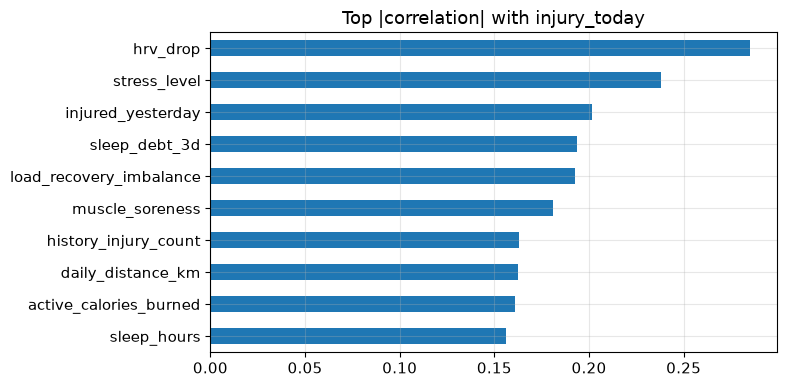

In [4]:
num_cols = df_demo.select_dtypes(include=[np.number]).columns
corr = df_demo[num_cols].corr()[LABEL_COL].drop(LABEL_COL).abs().sort_values(ascending=False).head(10)
corr.sort_values().plot(kind="barh", figsize=(8, 4), title="Top |correlation| with injury_today")
plt.tight_layout()
plt.show()

TOP_CORR_FEATURES = (
    df_demo.select_dtypes(include=[np.number])
    .corr()[LABEL_COL]
    .drop(LABEL_COL)
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
display(Markdown(f"**Top correlated features:** {', '.join(TOP_CORR_FEATURES[:5])}, …"))


### 2.2 — Correlation heatmap (model features)

Top 20 features by |correlation| with `injury_today`. Red = positive, blue = negative.


In [ ]:
contract_cols = [c for c in MODEL_FEATURE_COLUMNS if c in df_demo.columns]
plot_feature_correlation_heatmap(
    df_demo,
    contract_cols,
    LABEL_COL,
    top_n=20,
    title="Top-20 model features — Pearson correlation",
)


### 2.3 — Injury rate by feature quintiles

Does injury rate rise when the strongest signal moves? (Same idea as calibration bins after training.)


In [ ]:
for feat in TOP_CORR_FEATURES[:3]:
    plot_injury_rate_by_feature_bins(df_demo, feat, LABEL_COL)


## Part 3 — Features

35 features in production contract. Rolling MA7 added before training.


In [5]:
print(f"Model contract: {len(MODEL_FEATURE_COLUMNS)} features")
print(", ".join(MODEL_FEATURE_COLUMNS[:8]), "...")


Model contract: 35 features
bmi, age, body_fat_pct, vo2_max, history_injury_count, injured_yesterday, daily_distance_km, workout_intensity_minutes ...


## Part 4 — Train / holdout split

**By athlete** (20% holdout) — no row-level leakage.


In [6]:
split = make_train_split(df_demo, holdout_ratio=HOLDOUT_RATIO, seed=SEED)
display(pd.DataFrame([
    ("train rows", len(split.y_train)),
    ("holdout rows", len(split.y_test)),
    ("train injury rate", f"{split.y_train.mean():.2%}"),
    ("holdout injury rate", f"{split.y_test.mean():.2%}"),
    ("features", len(split.feature_columns)),
], columns=["item", "value"]))


,item,value
0,train rows,4800
1,holdout rows,1200
2,train injury rate,14.96%
3,holdout injury rate,18.08%
4,features,35


## Part 5 — Model selection (our algorithm)

**Problem:** ROC-AUC alone is not enough for injury UX.
- We need **high recall** (catch real injuries)
- We cap **false-positive rate** (avoid alert fatigue)
- Precision/F1 matter once safety gates are met

**Solution:** tiered threshold search + ranked policy (`pick_best_model` in `train_model.py`). The winner on this demo slice is chosen **automatically** — same code as `run_pipeline.py` on full data.


### 5.1 — Graded policy gates

Every candidate is evaluated against the gates in **Configuration** (applied in Bootstrap).


In [7]:
display_active_policy_gates("Graded policy gates")


,Gate,Value,Why
0,Recall hard minimum,0.80,Must catch ≥80% of holdout injuries @ operatin...
1,FPR maximum @ operating,0.55,Limit false alarms
2,Precision minimum,0.13,When all gates pass (Tier 0)
3,F1 minimum,0.22,When all gates pass (Tier 0)
4,Fixed comparison threshold,0.18,Baseline table before sweep tuning


### 5.2 — Train all candidates (live)

Each model: fit on train → predict holdout → threshold sweep.


In [8]:
display(Markdown(f"**Training {len(model_catalog())} models…** (~1–3 min on demo subset)"))
train_result = train_and_compare(split, verbose=True)
WINNER = train_result.best_model_name
OPERATING_THRESHOLD = train_result.best_operating_threshold
print(f"\nTraining complete. Winner on this slice: {WINNER} @ {OPERATING_THRESHOLD:.2f}")


**Training 5 models…** (~1–3 min on demo subset)


Data split diagnostics:
- total_rows: 6000
- train_rows: 4800
- test_rows: 1200
- injury_rate_overall: 0.1558
- injury_rate_train:   0.1496
- injury_rate_test:    0.1808
Training LogisticRegression...
Training RandomForest...
Training GradientBoosting...
Training XGBoostCalibratedTuned...
Training XGBoostDeep...

Training complete. Policy will pick among all 5 models.


### 5.3 — Baseline @ fixed threshold 0.18

Before our algorithm: who **fails** the graded gates at a single threshold?

This shows why a simple "pick highest ROC-AUC" or fixed cutoff is not enough.


In [9]:
fixed_gates = build_fixed_threshold_gate_table(train_result.results_df)
n_pass = int(fixed_gates["pass_all_gates"].sum())
n_fail = len(fixed_gates) - n_pass
display(Markdown(f"**{n_pass} / {len(fixed_gates)}** models pass all gates @ threshold {fixed_comparison_threshold():.2f}"))
if n_fail:
    display(Markdown(f"**{n_fail} models fail** — see `failed_gates` column"))

show_gates(fixed_gates[[
    "Model", "Recall", "Precision", "F1", "FPR", "ROC-AUC",
    "pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates", "failed_gates",
]], ["pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates"])


**1 / 5** models pass all gates @ threshold 0.18

**4 models fail** — see `failed_gates` column

,Model,Recall,Precision,F1,FPR,ROC-AUC,pass_recall_hard,pass_fpr,pass_precision,pass_f1,pass_all_gates,failed_gates
0,RandomForest,0.857143,0.271533,0.412417,0.507630,0.782280,PASS,PASS,PASS,PASS,PASS,—
1,XGBoostCalibratedTuned,0.599078,0.429043,0.500000,0.175992,0.794549,FAIL,PASS,PASS,PASS,FAIL,recall_hard
2,GradientBoosting,0.608295,0.409938,0.489796,0.193286,0.782655,FAIL,PASS,PASS,PASS,FAIL,recall_hard
3,XGBoostDeep,0.677419,0.366584,0.475728,0.258393,0.793302,FAIL,PASS,PASS,PASS,FAIL,recall_hard
4,LogisticRegression,0.917051,0.201826,0.330840,0.800610,0.764466,PASS,FAIL,PASS,PASS,FAIL,fpr


### 5.4 — Threshold sweep

For each model we scan many thresholds and record Recall / Precision / F1 / FPR.


Sweep grid: **32** thresholds × **5** models = **160** rows

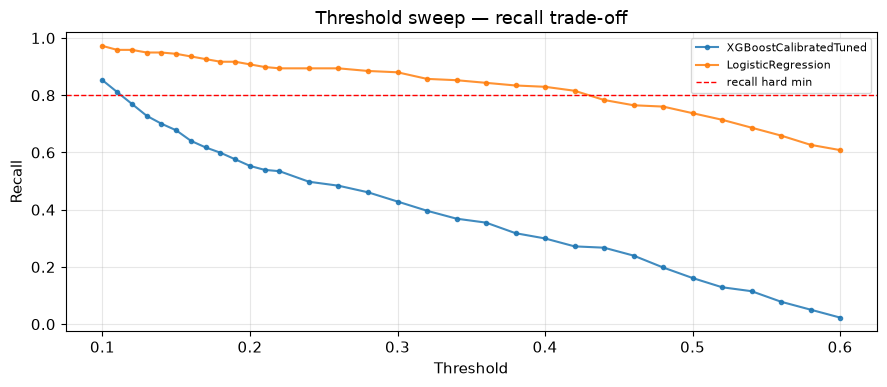

In [10]:
sweep_df = pd.DataFrame(train_result.threshold_rows)
display(Markdown(f"Sweep grid: **{sweep_df['Threshold'].nunique()}** thresholds × **{sweep_df['Model'].nunique()}** models = **{len(sweep_df)}** rows"))

# Recall vs threshold for 3 diverse models
sample_models = train_result.results_df.nlargest(1, "ROC-AUC")["Model"].tolist()
sample_models += train_result.results_df.nsmallest(1, "ROC-AUC")["Model"].tolist()
if WINNER not in sample_models:
    sample_models.append(WINNER)
sample_models = list(dict.fromkeys(sample_models))[:3]

fig, ax = plt.subplots(figsize=(9, 4))
for name in sample_models:
    sub = sweep_df[sweep_df["Model"] == name]
    ax.plot(sub["Threshold"], sub["Recall"], marker=".", label=name, alpha=0.85)
ax.axhline(policy_thresholds()["recall_hard_min"], color="red", ls="--", lw=1, label="recall hard min")
ax.set_xlabel("Threshold")
ax.set_ylabel("Recall")
ax.set_title("Threshold sweep — recall trade-off")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.5 — Our tiered algorithm (step by step)

For **each candidate**, pick one **operating point**:

| Tier | Rule | Meaning |
|------|------|---------|
| **0** | Recall ≥ hard min **and** FPR ≤ max **and** Precision ≥ min **and** F1 ≥ min | All gates pass — pick best F1 |
| **1** | Recall ≥ hard min **and** FPR ≤ max | Precision/F1 relaxed |
| **2** | Recall ≥ hard min only | FPR relaxed |
| **3** | Fallback | Best F1 among remaining thresholds |

Then **rank all models**: Tier (lower is better) → F1 → Precision → FPR → Recall → ROC-AUC → Brier.

```mermaid
flowchart TD
  A[All candidates] --> B[Threshold sweep each model]
  B --> C{Tier 0 all gates?}
  C -->|yes| T0[Best F1 in Tier 0]
  C -->|no| D{Tier 1 recall+FPR?}
  D -->|yes| T1[Best F1 in Tier 1]
  D -->|no| E{Tier 2 recall?}
  E -->|yes| T2[Best F1 in Tier 2]
  E -->|no| T3[Tier 3 fallback]
  T0 --> R[Rank: Tier then F1 Precision FPR Recall AUC Brier]
  T1 --> R
  T2 --> R
  T3 --> R
  R --> W[Winner = rank 1]
```


In [11]:
operating_table = build_operating_points_table(
    train_result.results_df,
    train_result.threshold_rows,
)
operating_table = add_selection_column(operating_table, WINNER)

tier_counts = (
    operating_table.groupby(["Tier", "Tier meaning"], as_index=False)
    .size()
    .rename(columns={"size": "models"})
)
display(Markdown("#### Models per tier"))
display(tier_counts)

display(Markdown("#### Full ranking after tiered operating-point search"))
show_gates(operating_table[[
    "Rank", "Model", "Selected", "Tier", "Threshold",
    "Recall", "Precision", "F1", "FPR", "ROC-AUC", "BrierScore",
    "pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates", "failed_gates",
]], ["pass_recall_hard", "pass_fpr", "pass_precision", "pass_f1", "pass_all_gates"])


#### Models per tier

,Tier,Tier meaning,models
0,0,All gates pass,5


#### Full ranking after tiered operating-point search

,Rank,Model,Selected,Tier,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore,pass_recall_hard,pass_fpr,pass_precision,pass_f1,pass_all_gates,failed_gates
0,1,LogisticRegression,True,0,0.42,0.815668,0.307826,0.446970,0.404883,0.764466,0.198198,PASS,PASS,PASS,PASS,PASS,—
1,2,XGBoostCalibratedTuned,False,0,0.11,0.811060,0.302926,0.441103,0.412004,0.794549,0.119395,PASS,PASS,PASS,PASS,PASS,—
2,3,XGBoostDeep,False,0,0.11,0.806452,0.301205,0.438596,0.413021,0.793302,0.118468,PASS,PASS,PASS,PASS,PASS,—
3,4,GradientBoosting,False,0,0.10,0.806452,0.300687,0.438048,0.414039,0.782655,0.115801,PASS,PASS,PASS,PASS,PASS,—
4,5,RandomForest,False,0,0.20,0.806452,0.286416,0.422705,0.443540,0.782280,0.124952,PASS,PASS,PASS,PASS,PASS,—


### 5.6 — Winner (`pick_best_model`)

This is the **algorithm output on this data slice** — not hardcoded. On full production data (`run_pipeline.py`), another candidate may win.


In [12]:
policy_pick = pick_best_model(train_result.results_df, train_result.threshold_rows)
assert policy_pick["Model"] == WINNER, "pick_best_model must match train_and_compare winner"

display(Markdown(f"## Selected winner: **{WINNER}** @ threshold **{OPERATING_THRESHOLD:.2f}**"))
display(pd.DataFrame([{
    "Model": policy_pick["Model"],
    "OperatingTier": int(policy_pick["OperatingTier"]),
    "Tier meaning": OPERATING_TIER_LABELS[int(policy_pick["OperatingTier"])],
    "Threshold": policy_pick["OperatingThreshold"],
    "Recall": policy_pick["OperatingRecall"],
    "Precision": policy_pick["OperatingPrecision"],
    "F1": policy_pick["OperatingF1"],
    "FPR": policy_pick["OperatingFPR"],
    "ROC-AUC": policy_pick["ROC-AUC"],
    "BrierScore": policy_pick["BrierScore"],
}]))

if len(operating_table) > 1:
    runner = operating_table.iloc[1]
    display(Markdown(
        f"Runner-up: **{runner['Model']}** (Tier {runner['Tier']}) — "
        f"F1 {runner['F1']:.3f} vs winner F1 {operating_table.iloc[0]['F1']:.3f}"
    ))


## Selected winner: **LogisticRegression** @ threshold **0.42**

,Model,OperatingTier,Tier meaning,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore
0,LogisticRegression,0,All gates pass,0.42,0.815668,0.307826,0.44697,0.404883,0.764466,0.198198


Runner-up: **XGBoostCalibratedTuned** (Tier 0) — F1 0.441 vs winner F1 0.447

### 5.7 — Fixed 0.18 vs policy operating point (winner)

Shows why threshold **tuning** matters.


In [13]:
w_fixed = fixed_gates.loc[fixed_gates["Model"] == WINNER].iloc[0]
w_policy = operating_table.loc[operating_table["Model"] == WINNER].iloc[0]
compare = pd.DataFrame([
    ("Threshold", w_fixed["Threshold"], w_policy["Threshold"]),
    ("Recall", w_fixed["Recall"], w_policy["Recall"]),
    ("Precision", w_fixed["Precision"], w_policy["Precision"]),
    ("F1", w_fixed["F1"], w_policy["F1"]),
    ("FPR", w_fixed["FPR"], w_policy["FPR"]),
    ("Pass all gates @ point", w_fixed["pass_all_gates"], w_policy["pass_all_gates"]),
], columns=["Metric", f"@ fixed {fixed_comparison_threshold():.2f}", "@ policy operating"])
display(compare)


,Metric,@ fixed 0.18,@ policy operating
0,Threshold,0.18,0.42
1,Recall,0.917051,0.815668
2,Precision,0.201826,0.307826
3,F1,0.33084,0.44697
4,FPR,0.80061,0.404883
5,Pass all gates @ point,False,True


### 5.8 — Final comparison table (all candidates, policy ranking)


In [14]:
final = operating_table[[
    "Rank", "Model", "Selected", "Tier", "Threshold",
    "Recall", "Precision", "F1", "FPR", "ROC-AUC", "BrierScore",
]]
display(final)


,Rank,Model,Selected,Tier,Threshold,Recall,Precision,F1,FPR,ROC-AUC,BrierScore
0,1,LogisticRegression,True,0,0.42,0.815668,0.307826,0.446970,0.404883,0.764466,0.198198
1,2,XGBoostCalibratedTuned,False,0,0.11,0.811060,0.302926,0.441103,0.412004,0.794549,0.119395
2,3,XGBoostDeep,False,0,0.11,0.806452,0.301205,0.438596,0.413021,0.793302,0.118468
3,4,GradientBoosting,False,0,0.10,0.806452,0.300687,0.438048,0.414039,0.782655,0.115801
4,5,RandomForest,False,0,0.20,0.806452,0.286416,0.422705,0.443540,0.782280,0.124952


### 5.9 — Demo winner feature importance (presentation slice)

Weights on the small demo can differ from production. **Part 7.2** shows the promoted model on the full 359k-row run.


,feature,importance
30,hrv_drop,0.735044
9,elevation_gained_m,0.589977
10,floors_climbed,0.564630
4,history_injury_count,0.386306
31,load_recovery_imbalance,0.379907
14,active_calories_burned,0.318820
27,acwr_ratio,0.180477
5,injured_yesterday,0.177142
20,nutrition_intake_calories,0.145442
15,sleep_hours,0.112901


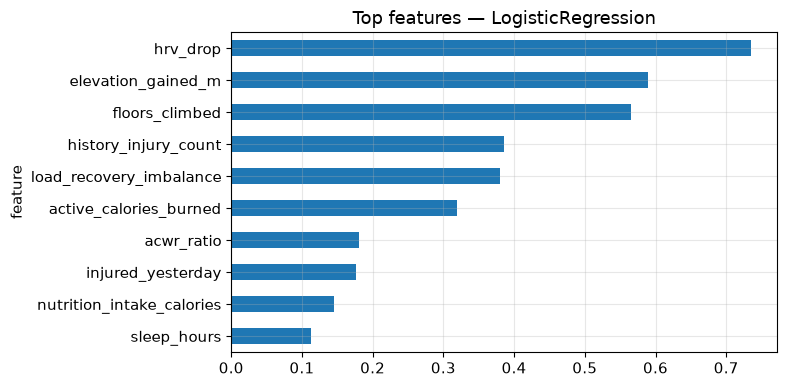

In [15]:
fi = train_result.importance_df
if fi is not None:
    display(fi.head(10))
    fi.head(10).sort_values("importance").plot(kind="barh", x="feature", y="importance", figsize=(8, 4), legend=False, title=f"Top features — {WINNER}")
    plt.tight_layout()
    plt.show()


## Part 6 — Calibration (demo winner on holdout)

**Calibration curve:** predicted risk vs observed injury rate on the **demo** holdout.

**Risk bins table (poster):** groups holdout predictions into score bands and shows the **real** injury rate in each band.

> Shipped calibration and risk bins from the full run are in **Part 7**. App `riskLevel` uses **0–20 / 21–70 / 71–100** (`risk_levels.py`); analysis bins here are **0–20 / 21–50 / 51–100**.


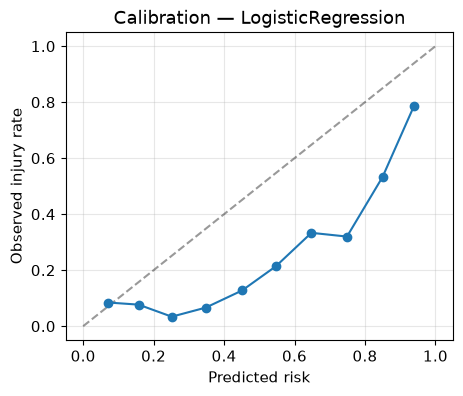

,bin,samples,injury_rate
0,green_0_20,253,0.079051
1,yellow_20_50,500,0.074000
2,red_50_100,447,0.357942


In [16]:
cal = train_result.calibration_bins.get(WINNER)
if cal is not None:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.plot(cal["mean_predicted_risk"], cal["fraction_positive"], "o-")
    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed injury rate")
    ax.set_title(f"Calibration — {WINNER}")
    plt.show()

display(Markdown("### Risk bins — observed injury rate by score band"))
display(format_risk_bins_table(train_result.risk_bins_df))
display(Markdown("_Raw holdout counts (same data):_"))
display(train_result.risk_bins_df)


## Part 7 — Production decision evidence (promoted run)

Charts and tables from the **full training run** (`run_pipeline.py` on ~359k rows). These artifacts — not the demo slice above — drove what ships today: model choice, operating threshold, and feature emphasis.

Source: `ML_model/artifacts/20260629_184034/` + `promoted.json`.


### 7.1 — Promoted run summary & model comparison


In [ ]:
prod_manifest = load_production_manifest()
PROD_WINNER = prod_manifest["winner"]
PROD_THRESHOLD = float(prod_manifest["threshold"])

display(Markdown(
    f"**Run** `{prod_manifest['run_id']}` · **rows** {prod_manifest['dataset_rows']:,} · "
    f"**winner** `{PROD_WINNER}` · **operating threshold** `{PROD_THRESHOLD:.2f}`"
))
display(Markdown("**Policy gates at promotion**"))
display(pd.DataFrame([prod_manifest["policy"]]).T.rename(columns={0: "value"}))
display(Markdown("**Winner @ operating threshold (holdout)**"))
display(production_winner_metrics_table(prod_manifest))

model_cmp = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "model_comparison.csv")
model_cmp = model_cmp.sort_values("F1@Threshold", ascending=False)
model_cmp["Selected"] = model_cmp["Model"] == PROD_WINNER
display(Markdown("**All models — ranked by F1 @ tier-selected threshold**"))
display(model_cmp[[
    "Model", "Selected", "Recall@Threshold", "Precision@Threshold",
    "F1@Threshold", "FPR@Threshold", "ROC-AUC", "BrierScore",
]])


### 7.2 — Feature importance (shipped model)

Top drivers from the promoted `XGBoostCalibratedTuned` run — used to explain alerts and prioritize monitoring (`hrv_drop`, `stress_level`, `sleep_debt_3d`, …).


In [ ]:
prod_fi = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "feature_importance.csv")
top_n = 12
display(prod_fi.head(top_n))
prod_fi.head(top_n).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", figsize=(8, 4), legend=False,
    title=f"Production feature importance — {PROD_WINNER}",
)
plt.tight_layout()
plt.show()


### 7.3 — Calibration & risk bins (full holdout)


In [ ]:
prod_cal = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "calibration_curve_data.csv")
plot_calibration_from_artifact(
    prod_cal,
    PROD_WINNER,
    title=f"Calibration — {PROD_WINNER} (production holdout)",
)

prod_bins = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "risk_bins_summary.csv")
display(Markdown("### Risk bins — observed injury rate by score band (production)"))
display(format_risk_bins_table(prod_bins))
display(Markdown("_Raw holdout counts:_"))
display(prod_bins)


### 7.4 — Threshold sweep → why 0.10?

Tier selection picks the best operating point per model under recall/FPR gates. The promoted winner landed at **0.10** — recall ≥ 0.80 with FPR within policy.


In [ ]:
prod_sweep = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "threshold_sweep.csv")
plot_threshold_sweep_metric(
    prod_sweep, PROD_WINNER, "F1", operating_threshold=PROD_THRESHOLD,
)
plot_threshold_sweep_metric(
    prod_sweep, PROD_WINNER, "Recall", operating_threshold=PROD_THRESHOLD,
)
plot_threshold_sweep_metric(
    prod_sweep, PROD_WINNER, "FPR", operating_threshold=PROD_THRESHOLD,
)

best_pts = pd.read_csv(PRODUCTION_ARTIFACTS_DIR / "best_operating_points.csv")
display(Markdown("**Best operating point per model (tier algorithm output)**"))
display(best_pts)


### 7.5 — PR curve & confusion matrix @ production threshold

Re-scores the **benchmark athlete holdout** from `athlete_injury_data.csv` (same split as `run_pipeline.py`) using the promoted `injury_model.pkl`. Takes ~15–20s — reads the full training CSV once.


In [ ]:
scored = score_production_on_benchmark_holdout()
if scored is None:
    display(Markdown(
        "_`injury_model.pkl` or `athlete_injury_data.csv` not found — run `python ML_model/run_pipeline.py` first._"
    ))
else:
    y_prod, proba_prod, thr_prod = scored
    plot_pr_curve(
        y_prod,
        proba_prod,
        operating_threshold=thr_prod,
        title=f"PR curve — {PROD_WINNER} (benchmark holdout)",
    )
    plot_confusion_at_threshold(
        y_prod,
        proba_prod,
        thr_prod,
        title=f"Confusion @ {thr_prod:.2f} — {PROD_WINNER}",
    )


## Summary


In [17]:
display(pd.DataFrame([
    ("Demo data", f"{SUBSET_ATHLETES} athletes × {SUBSET_DAYS} days"),
    ("Models trained (demo)", len(train_result.results_df)),
    ("Pass all gates @ fixed threshold", f"{int(fixed_gates['pass_all_gates'].sum())} / {len(fixed_gates)}"),
    ("Winner (demo algorithm)", WINNER),
    ("Operating threshold (demo)", f"{OPERATING_THRESHOLD:.2f}"),
    ("---", "---"),
    ("Production run", PRODUCTION_REF["promoted_run_id"]),
    ("Production rows", f"{PRODUCTION_REF['dataset_rows']:,}"),
    ("Shipped model", PRODUCTION_REF["promoted_winner"]),
    ("Shipped threshold", f"{PRODUCTION_REF['operating_threshold']:.2f}"),
], columns=["Item", "Value"]))

display(Markdown(
    "_Same selection code as `run_pipeline.py`. On **full data** or **real athletes**, the winner may differ — "
    "then re-run the pipeline; the app loads whatever is in `promoted.json`._"
))


,Item,Value
0,Demo data,50 athletes × 120 days
1,Models trained,5
2,Pass all gates @ fixed 0.18,1 / 5
3,Winner (algorithm),LogisticRegression
4,Operating threshold,0.42
5,Winner tier,0


_Demo numbers differ from full production run. Algorithm and gates are identical to `run_pipeline.py`._